# 01. Exploratory Data Analysis

## Project Context

This notebook frames churn as a business retention problem, not just a classification task. The goal is to identify where churn is concentrated, which customer segments appear most exposed, and which patterns should inform future feature engineering, modeling, SHAP-based explanations, customer-level reason codes, and retention recommendations.

The analysis below uses the cleaned Telco dataset and focuses on business interpretation first, with simple, readable visuals throughout.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
px.defaults.template = "plotly_white"

df = pd.read_csv("../data/processed/telco_churn_clean.csv")

def summarize_churn(frame: pd.DataFrame, group_col: str) -> pd.DataFrame:
    summary = (
        frame.groupby(group_col, dropna=False)
        .agg(
            customers=("churn", "size"),
            churners=("churn", "sum"),
            churn_rate=("churn", "mean"),
        )
        .reset_index()
    )
    return summary


Matplotlib is building the font cache; this may take a moment.


## Load Clean Data

The notebook uses the cleaned dataset located at `../data/processed/telco_churn_clean.csv`.

In [2]:
display(df.head())

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Dataset Overview

This section checks the dataset shape, data types, missing values, and descriptive statistics before moving into business segmentation.

In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

print("\nData types and non-null counts:")
df.info()

missing = df.isna().sum().sort_values(ascending=False).to_frame(name="missing_values")
display(missing)

display(df.describe(include="all").T)

Rows: 7,032
Columns: 21

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7032 non-null   str    
 1   gender             7032 non-null   str    
 2   senior_citizen     7032 non-null   int64  
 3   partner            7032 non-null   str    
 4   dependents         7032 non-null   str    
 5   tenure             7032 non-null   int64  
 6   phone_service      7032 non-null   str    
 7   multiple_lines     7032 non-null   str    
 8   internet_service   7032 non-null   str    
 9   online_security    7032 non-null   str    
 10  online_backup      7032 non-null   str    
 11  device_protection  7032 non-null   str    
 12  tech_support       7032 non-null   str    
 13  streaming_tv       7032 non-null   str    
 14  streaming_movies   7032 non-null   str    
 15  contract_type      7032 no

,missing_values
customer_id,0
device_protection,0
total_charges,0
monthly_charges,0
payment_method,0
paperless_billing,0
contract_type,0
streaming_movies,0
streaming_tv,0
tech_support,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,7032,7032,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7032,2,Male,3549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
senior_citizen,7032.0,NaN,NaN,NaN,0.1624,0.368844,0.0,0.0,0.0,0.0,1.0
partner,7032,2,No,3639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dependents,7032,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7032.0,NaN,NaN,NaN,32.421786,24.54526,1.0,9.0,29.0,55.0,72.0
phone_service,7032,2,Yes,6352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
multiple_lines,7032,3,No,3385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet_service,7032,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
online_security,7032,3,No,3497,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Target Distribution

We first establish the baseline churn rate. This defines the scale of the retention challenge and helps interpret all segment-level patterns that follow.

Overall churn rate: 26.58%


,status,customers,share_pct
0,No churn,5163,73.42
1,Churn,1869,26.58


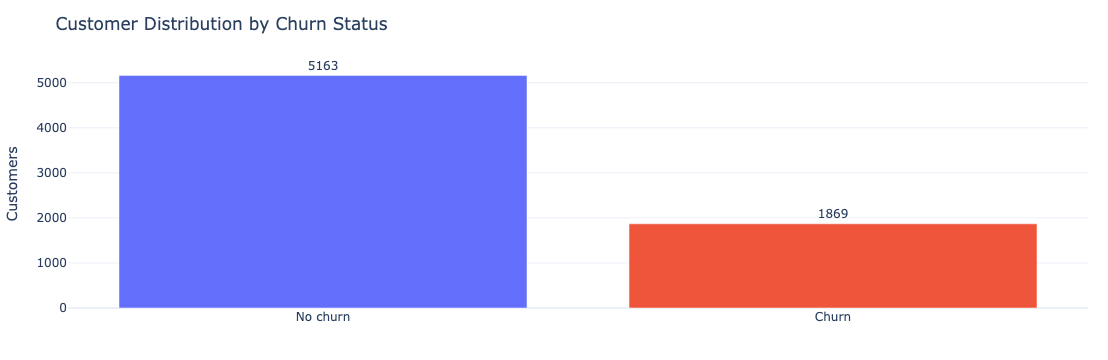

In [4]:
target_table = (
    df["churn"]
    .map({0: "No churn", 1: "Churn"})
    .value_counts()
    .reindex(["No churn", "Churn"])
    .reset_index()
)
target_table.columns = ["status", "customers"]
target_table["share_pct"] = (target_table["customers"] / len(df) * 100).round(2)

overall_churn_rate = df["churn"].mean()
print(f"Overall churn rate: {overall_churn_rate:.2%}")
display(target_table)

fig = px.bar(
    target_table,
    x="status",
    y="customers",
    text="customers",
    color="status",
    title="Customer Distribution by Churn Status",
    labels={"status": "Churn status", "customers": "Customers"},
)
fig.update_traces(textposition="outside", showlegend=False)
fig.update_layout(xaxis_title="", yaxis_title="Customers", margin=dict(l=20, r=20, t=60, b=20))
fig.show()

## Churn by Contract Type

Contract structure is one of the clearest business levers in churn analysis. Longer commitments usually indicate stronger retention, while month-to-month customers are typically easier to lose and easier to convert with the right offer.

,contract_type,customers,churners,churn_rate_pct
0,Month-to-month,3875,1655,42.71
1,One year,1472,166,11.28
2,Two year,1685,48,2.85


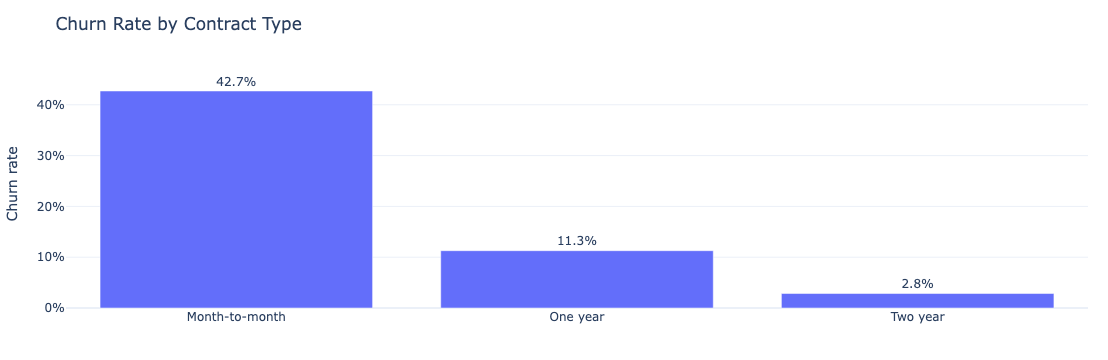

In [5]:
contract_summary = summarize_churn(df, "contract_type").sort_values("churn_rate", ascending=False)
contract_display = contract_summary.copy()
contract_display["churn_rate_pct"] = (contract_display["churn_rate"] * 100).round(2)
display(contract_display[["contract_type", "customers", "churners", "churn_rate_pct"]])

fig = px.bar(
    contract_summary,
    x="contract_type",
    y="churn_rate",
    text=contract_summary["churn_rate"].map(lambda x: f"{x:.1%}"),
    title="Churn Rate by Contract Type",
    labels={"contract_type": "Contract type", "churn_rate": "Churn rate"},
)
fig.update_traces(textposition="outside")
fig.update_yaxes(tickformat=".0%")
fig.update_layout(xaxis_title="", yaxis_title="Churn rate", margin=dict(l=20, r=20, t=60, b=20))
fig.show()

**Business interpretation**

The contract signal is usually the strongest retention clue in this dataset. Month-to-month customers are expected to represent the highest churn concentration, while one-year and two-year customers should show materially lower churn. From a business perspective, this points to contract structure as a primary lever for retention offers, renewal nudges, and proactive save campaigns.

## Churn by Payment Method

Payment behavior can act as a proxy for customer convenience, engagement, and operational friction. It is useful to compare churn across payment channels because some methods are more associated with automatic renewal and lower customer effort.

,payment_method,customers,churners,churn_rate_pct
2,Electronic check,2365,1071,45.29
3,Mailed check,1604,308,19.20
0,Bank transfer (automatic),1542,258,16.73
1,Credit card (automatic),1521,232,15.25


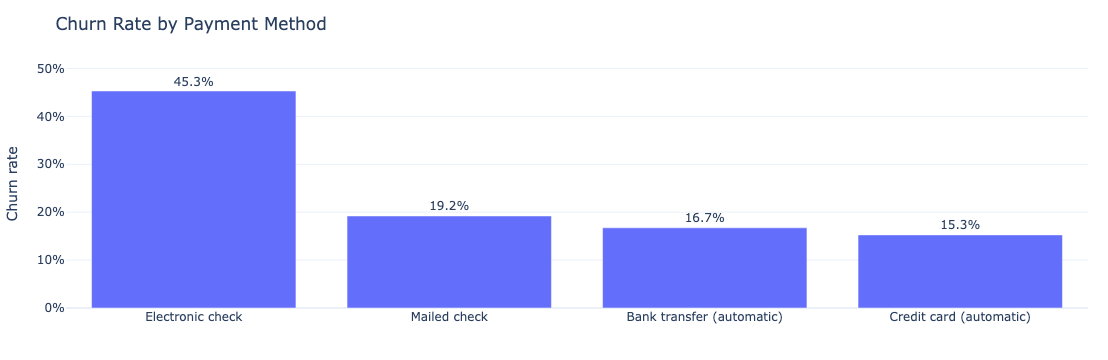

In [6]:
payment_summary = summarize_churn(df, "payment_method").sort_values("churn_rate", ascending=False)
payment_display = payment_summary.copy()
payment_display["churn_rate_pct"] = (payment_display["churn_rate"] * 100).round(2)
display(payment_display[["payment_method", "customers", "churners", "churn_rate_pct"]])

fig = px.bar(
    payment_summary,
    x="payment_method",
    y="churn_rate",
    text=payment_summary["churn_rate"].map(lambda x: f"{x:.1%}"),
    title="Churn Rate by Payment Method",
    labels={"payment_method": "Payment method", "churn_rate": "Churn rate"},
)
fig.update_traces(textposition="outside")
fig.update_yaxes(tickformat=".0%")
fig.update_layout(xaxis_title="", yaxis_title="Churn rate", margin=dict(l=20, r=20, t=60, b=20))
fig.show()

**Business interpretation**

Payment method can be a practical retention segmentation variable. Higher churn among manual or less automated payment methods often suggests more fragile customer commitment or weaker service lock-in. If that pattern appears here, payment channel can support targeted billing migration campaigns and low-friction renewal prompts.

## Churn by Tenure

Tenure is one of the most intuitive early-warning indicators in churn analysis. Customers in their first months often have the highest uncertainty, while long-tenured customers usually show much stronger retention.

,tenure_bucket,customers,churners,churn_rate_pct
0,0-6 months,1470,784,53.33
1,7-12 months,705,253,35.89
2,13-24 months,1024,294,28.71
3,25-48 months,1594,325,20.39
4,49-72 months,2239,213,9.51


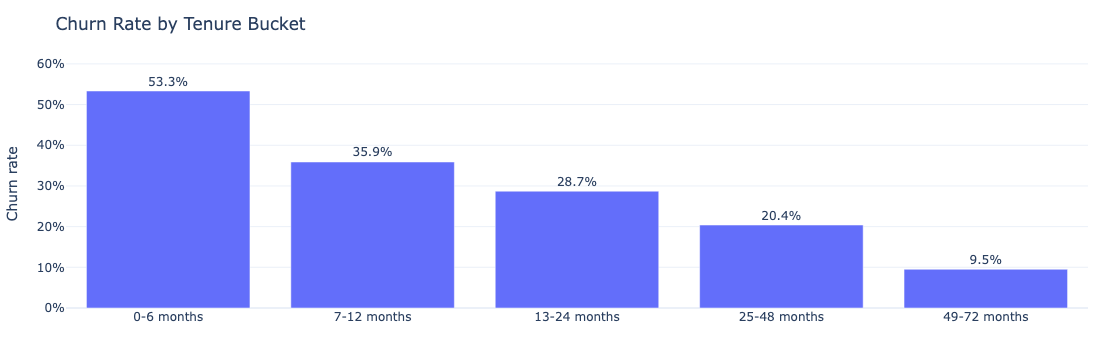

In [7]:
tenure_bins = [0, 6, 12, 24, 48, 72]
tenure_labels = ["0-6 months", "7-12 months", "13-24 months", "25-48 months", "49-72 months"]
df["tenure_bucket"] = pd.cut(df["tenure"], bins=tenure_bins, labels=tenure_labels, include_lowest=True)

tenure_summary = summarize_churn(df, "tenure_bucket").sort_values("tenure_bucket")
tenure_display = tenure_summary.copy()
tenure_display["churn_rate_pct"] = (tenure_display["churn_rate"] * 100).round(2)
display(tenure_display[["tenure_bucket", "customers", "churners", "churn_rate_pct"]])

fig = px.bar(
    tenure_summary,
    x="tenure_bucket",
    y="churn_rate",
    text=tenure_summary["churn_rate"].map(lambda x: f"{x:.1%}"),
    title="Churn Rate by Tenure Bucket",
    labels={"tenure_bucket": "Tenure bucket", "churn_rate": "Churn rate"},
)
fig.update_traces(textposition="outside")
fig.update_yaxes(tickformat=".0%")
fig.update_layout(xaxis_title="", yaxis_title="Churn rate", margin=dict(l=20, r=20, t=60, b=20))
fig.show()

**Business interpretation**

Tenure typically reveals onboarding risk. If churn is concentrated in the first 6 to 12 months, the retention strategy should prioritize early-life customer support, education, and proactive check-ins rather than broad, untargeted incentives.

## Churn by Monthly Charges

Monthly spend is a direct value lens. Customers with higher recurring charges can be more sensitive to perceived value, product fit, and support experience. For this analysis, monthly charges are segmented into quartile-based bands.

,monthly_spend_band,customers,avg_monthly_charges,churners,churn_rate_pct
0,Low,1758,22.25,199,11.32
1,Medium,1761,55.75,433,24.59
2,High,1755,80.34,659,37.55
3,Very High,1758,100.90,578,32.88


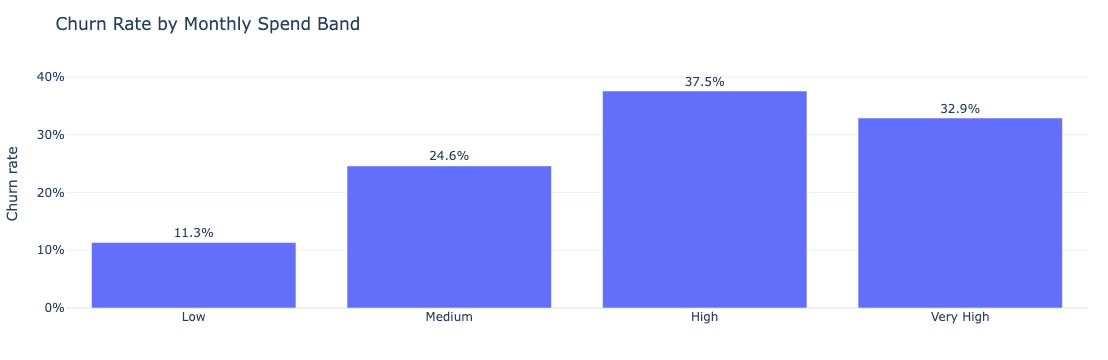

In [8]:
df["monthly_spend_band"] = pd.qcut(
    df["monthly_charges"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"],
)

monthly_summary = (
    df.groupby("monthly_spend_band", dropna=False)
    .agg(
        customers=("churn", "size"),
        avg_monthly_charges=("monthly_charges", "mean"),
        churners=("churn", "sum"),
        churn_rate=("churn", "mean"),
    )
    .reset_index()
    .sort_values("monthly_spend_band")
)

monthly_display = monthly_summary.copy()
monthly_display["avg_monthly_charges"] = monthly_display["avg_monthly_charges"].round(2)
monthly_display["churn_rate_pct"] = (monthly_display["churn_rate"] * 100).round(2)
display(monthly_display[["monthly_spend_band", "customers", "avg_monthly_charges", "churners", "churn_rate_pct"]])

fig = px.bar(
    monthly_summary,
    x="monthly_spend_band",
    y="churn_rate",
    text=monthly_summary["churn_rate"].map(lambda x: f"{x:.1%}"),
    title="Churn Rate by Monthly Spend Band",
    labels={"monthly_spend_band": "Monthly spend band", "churn_rate": "Churn rate"},
)
fig.update_traces(textposition="outside")
fig.update_yaxes(tickformat=".0%")
fig.update_layout(xaxis_title="", yaxis_title="Churn rate", margin=dict(l=20, r=20, t=60, b=20))
fig.show()

**Business interpretation**

Monthly charges help separate low-value, low-risk customers from higher-value segments that may be more sensitive to price and service friction. If churn rises as spend increases, the business should treat high-billing customers as a priority segment for retention offers and service recovery.

The relationship may not be perfectly linear, so the goal here is to identify where retention pressure becomes meaningful rather than to assume every high-spend customer is equally at risk.

## Churn by Internet Service and Support Services

Service bundle quality is often a practical driver of retention. Customers who subscribe to support, security, and protection services may be more embedded in the product, while customers without those services may experience lower perceived value or weaker switching costs.

,service,status,customers,churners,churn_rate_pct
0,internet_service,DSL,2416,459,19.00
1,internet_service,Fiber optic,3096,1297,41.89
2,internet_service,No,1520,113,7.43
3,tech_support,No,3472,1446,41.65
4,tech_support,No internet service,1520,113,7.43
5,tech_support,Yes,2040,310,15.20
6,online_security,No,3497,1461,41.78
7,online_security,No internet service,1520,113,7.43
8,online_security,Yes,2015,295,14.64
9,online_backup,No,3087,1233,39.94


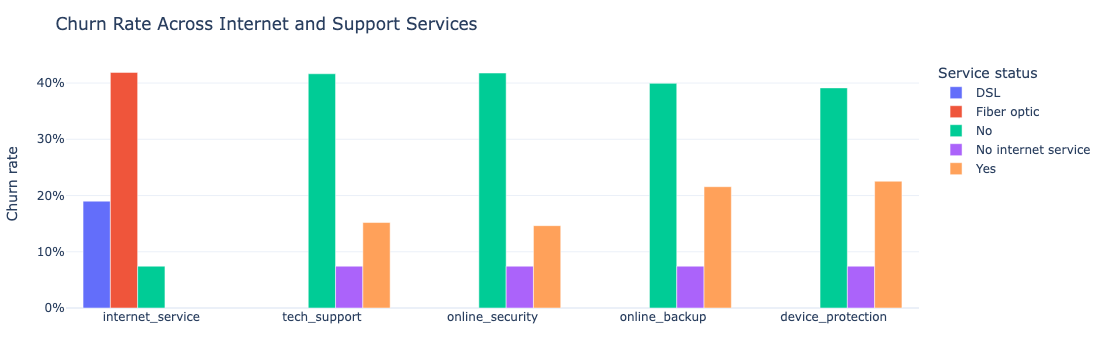

In [9]:
service_columns = [
    "internet_service",
    "tech_support",
    "online_security",
    "online_backup",
    "device_protection",
]

service_tables = []
for col in service_columns:
    temp = summarize_churn(df, col).rename(columns={col: "status"})
    temp.insert(0, "service", col)
    service_tables.append(temp)

support_summary = pd.concat(service_tables, ignore_index=True)
support_display = support_summary.copy()
support_display["churn_rate_pct"] = (support_display["churn_rate"] * 100).round(2)
display(support_display[["service", "status", "customers", "churners", "churn_rate_pct"]])

fig = px.bar(
    support_summary,
    x="service",
    y="churn_rate",
    color="status",
    barmode="group",
    title="Churn Rate Across Internet and Support Services",
    labels={"service": "Service", "churn_rate": "Churn rate", "status": "Service status"},
    category_orders={"service": service_columns},
)
fig.update_yaxes(tickformat=".0%")
fig.update_layout(xaxis_title="", yaxis_title="Churn rate", margin=dict(l=20, r=20, t=60, b=20))
fig.show()

**Business interpretation**

Internet service type and support add-ons are likely to separate higher-risk customers from more retained customers. In particular, fiber customers, customers without technical support, and customers without security or backup services often represent a meaningful retention opportunity. These customers may not only be more likely to churn, but also more valuable to save because they are tied to richer service bundles.

## Segment-Level Risk View

The table below combines contract type, tenure bucket, and monthly spend band to create a first-pass retention prioritization view.

`estimated_value_at_risk` is an exploratory proxy only. It is calculated as churners multiplied by average monthly charges within the segment, so it should be treated as a directional prioritization signal rather than a final financial model.

In [10]:
segment_table = (
    df.groupby(["contract_type", "tenure_bucket", "monthly_spend_band"], dropna=False)
    .agg(
        customers=("churn", "size"),
        churners=("churn", "sum"),
        churn_rate=("churn", "mean"),
        avg_monthly_charges=("monthly_charges", "mean"),
    )
    .reset_index()
)
segment_table["estimated_value_at_risk"] = segment_table["churners"] * segment_table["avg_monthly_charges"]
segment_table = segment_table.sort_values("estimated_value_at_risk", ascending=False)

segment_display = segment_table.copy()
segment_display["churn_rate_pct"] = (segment_display["churn_rate"] * 100).round(2)
segment_display["avg_monthly_charges"] = segment_display["avg_monthly_charges"].round(2)
segment_display["estimated_value_at_risk"] = segment_display["estimated_value_at_risk"].round(2)
display(segment_display[["contract_type", "tenure_bucket", "monthly_spend_band", "customers", "churners", "churn_rate_pct", "avg_monthly_charges", "estimated_value_at_risk"]])


,contract_type,tenure_bucket,monthly_spend_band,customers,churners,churn_rate_pct,avg_monthly_charges,estimated_value_at_risk
2,Month-to-month,0-6 months,High,404,295,73.02,78.91,23277.14
1,Month-to-month,0-6 months,Medium,491,261,53.16,54.61,14253.50
15,Month-to-month,25-48 months,Very High,291,127,43.64,99.11,12587.23
11,Month-to-month,13-24 months,Very High,180,101,56.11,97.15,9812.18
10,Month-to-month,13-24 months,High,245,109,44.49,81.01,8830.60
3,Month-to-month,0-6 months,Very High,119,92,77.31,95.66,8800.42
6,Month-to-month,7-12 months,High,194,108,55.67,79.84,8622.52
14,Month-to-month,25-48 months,High,244,96,39.34,81.38,7812.92
7,Month-to-month,7-12 months,Very High,95,73,76.84,97.71,7132.98
39,One year,49-72 months,Very High,310,63,20.32,102.82,6477.69


## Initial Business Insights

The EDA points to a small number of segments carrying disproportionate churn risk:

- Churn is concentrated in month-to-month contracts, which should be the first segment reviewed by retention teams.
- Early-tenure customers appear materially more vulnerable than long-tenured customers, suggesting onboarding and first-90-day support matter.
- Payment method may reflect convenience and commitment, especially where automated payments differ from manual billing behavior.
- Monthly charges appear to influence churn sensitivity, especially in higher-value segments that deserve closer commercial review.
- Support and security services appear connected to retention, which makes service bundling and proactive assistance relevant retention levers.

Taken together, the analysis suggests that churn is not random. It is concentrated in identifiable business segments that can be prioritized through targeted retention actions rather than generic discounting.

## Retention Hypotheses

These hypotheses will guide the next phase of feature engineering and model design:

- Month-to-month customers may benefit from contract upgrade offers, commitment incentives, or renewal-oriented outreach.
- Early-tenure customers may need onboarding support, product education, or a structured first-90-day retention journey.
- High-spend, high-risk customers may warrant human review because the value of saving them is likely higher than the cost of intervention.
- Customers without support or security services may respond to proactive service activation, education, or bundle recommendations.
- Retention prioritization should combine churn risk and customer value, not churn risk alone.

These are hypotheses, not conclusions. They should be validated in the modeling and business-rule phases.

## Next Steps

The next phase will turn these EDA insights into engineered features and model-ready inputs. That work will also prepare the project for churn prediction, SHAP explanations, customer-level reason codes, and retention recommendation logic.